In [1]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import keras
from keras import optimizers
#from keras.preprocessing.image import ImageDataGenerator, load_img, image
#from keras.preprocessing.image import load_img, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

In [2]:
import os
import pandas as pd

img_path = '256_unlabeled/'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(img_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['1' if f.endswith('yellow1.png') else '0' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
df.head()

(432, 2)


,filename,category
0,m05_tile256_x03328_y00512_yellow0.png,0
1,m05_tile256_x02560_y00000_yellow1.png,1
2,m05_tile256_x01280_y01280_yellow1.png,1
3,m05_tile256_x01024_y03328_yellow0.png,0
4,m05_tile256_x01280_y00256_yellow0.png,0


In [3]:
df['category'].value_counts()

category
0    377
1     55
Name: count, dtype: int64

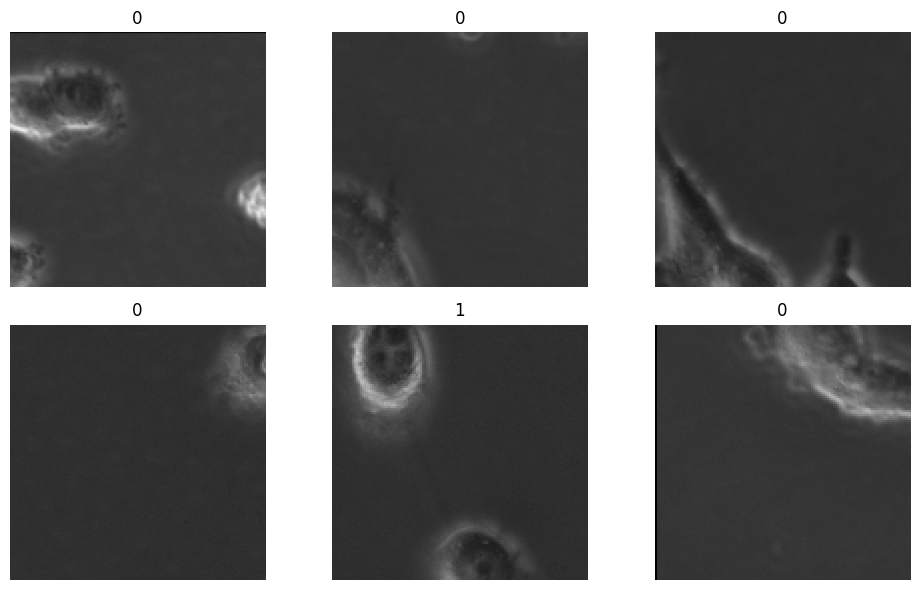

In [4]:
import os, random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

IMG_DIR = '256_unlabeled/'   # keep as directory
IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    full_path = os.path.join(IMG_DIR, filename)  # don't overwrite IMG_DIR
    image = load_img(full_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Model

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

INPUT_SHAPE = (178, 218, 3)

class_mode="binary"

# VGG16 base
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze last two layers with weights
unfroze = 0
for layer in reversed(vgg_base.layers):
    if layer.weights:
        layer.trainable = True
        unfroze += 1
        if unfroze == 2:
            break

# Verify trainability
for i, layer in enumerate(vgg_base.layers):
    print(f"{i:02d} {layer.name:25s} trainable={layer.trainable}")

# Explicit input layer
# 'This makes the model immediately callable and avoids a lot of “undefined output” issues.'
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization

INPUT_SHAPE = (178, 218, 3)


# Build Sequential model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")   # categorical output
])

# Callbacks
earlystop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model.celeb_man_female.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


#model.compile(
#    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#    loss="binary_crossentropy",
#    metrics=["accuracy"]
#)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

model.summary()

00 input_layer               trainable=False
01 block1_conv1              trainable=False
02 block1_conv2              trainable=False
03 block1_pool               trainable=False
04 block2_conv1              trainable=False
05 block2_conv2              trainable=False
06 block2_pool               trainable=False
07 block3_conv1              trainable=False
08 block3_conv2              trainable=False
09 block3_conv3              trainable=False
10 block3_pool               trainable=False
11 block4_conv1              trainable=False
12 block4_conv2              trainable=False
13 block4_conv3              trainable=False
14 block4_pool               trainable=False
15 block5_conv1              trainable=False
16 block5_conv2              trainable=True
17 block5_conv3              trainable=True
18 block5_pool               trainable=False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,966,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,681,537 (63.64 MB)

 Trainable params: 6,686,209 (25.51 MB)

 Non-trainable params: 9,995,328 (38.13 MB)

Data preparation

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1) Train/Validation split (20% validation)
train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]  # keeps class balance consistent
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

print("\nTrain class counts:")
print(train_df["category"].value_counts())

print("\nValid class counts:")
print(valid_df["category"].value_counts())

# 2) Batch size
BATCH_SIZE = 20

# 3) Image generators (use VGG16 preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 4) Flow from dataframe
TARGET_SIZE = (178, 218)

import math
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_DIR = "256_unlabeled/"   # <- the one you just validated
TARGET_SIZE = (178, 218)
BATCH_SIZE = 20

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMG_DIR,          # <- FIX
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=IMG_DIR,          # <- FIX
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("class_indices:", train_generator.class_indices)

steps_per_epoch = math.ceil(train_generator.n / train_generator.batch_size)
validation_steps = math.ceil(valid_generator.n / valid_generator.batch_size)

print("Found train:", train_generator.n, "valid:", valid_generator.n)
print("steps_per_epoch:", steps_per_epoch, "validation_steps:", validation_steps)


Train shape: (345, 2)
Valid shape: (87, 2)

Train class counts:
category
0    301
1     44
Name: count, dtype: int64

Valid class counts:
category
0    76
1    11
Name: count, dtype: int64
Found 345 validated image filenames belonging to 2 classes.
Found 87 validated image filenames belonging to 2 classes.
class_indices: {'0': 0, '1': 1}
Found train: 345 valid: 87
steps_per_epoch: 18 validation_steps: 5


# Train model - more detailed version, accuracy for each step within an epoch

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback

class BatchHistory(Callback):
    def on_train_begin(self, logs=None):
        self.batch_loss = []
        self.batch_acc = []
        self.epoch_ends = []  # global-step index where each epoch ends

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.batch_loss.append(logs.get("loss"))
        # depending on your compile(), this might be "accuracy" or "binary_accuracy"
        self.batch_acc.append(logs.get("accuracy", logs.get("binary_accuracy")))

    def on_epoch_end(self, epoch, logs=None):
        # mark the end step for this epoch
        self.epoch_ends.append(len(self.batch_loss))

batch_hist = BatchHistory()

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[earlystop, checkpoint, batch_hist],
    verbose=1
)


Epoch 1/30


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5382 - auc: 0.5053 - loss: 0.8646 - precision: 0.1539 - recall: 0.5392
Epoch 1: val_loss improved from inf to 2.00839, saving model to model.celeb_man_female.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5398 - auc: 0.5098 - loss: 0.8633 - precision: 0.1550 - recall: 0.5443 - val_accuracy: 0.4023 - val_auc: 0.3810 - val_loss: 2.0084 - val_precision: 0.0638 - val_recall: 0.2727
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8083 - auc: 0.9881 - loss: 0.4920 - precision: 0.4102 - recall: 1.0000
Epoch 2: val_loss did not improve from 2.00839
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8073 - auc: 0.9877 - loss: 0.4945 - precision: 0.4084 - recall: 1.0000 - val_accuracy: 0.3908 - val_auc: 0.4785 - val_loss: 2.1628 - val_precision: 0.1111 - val_recall: 0.5455
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8579 - auc: 0.9872 - loss: 0.4318 - precision: 0.4218 - recall: 1.0000
Epoch 3: va

# Detailed plot, shows squiggles within each epoch.

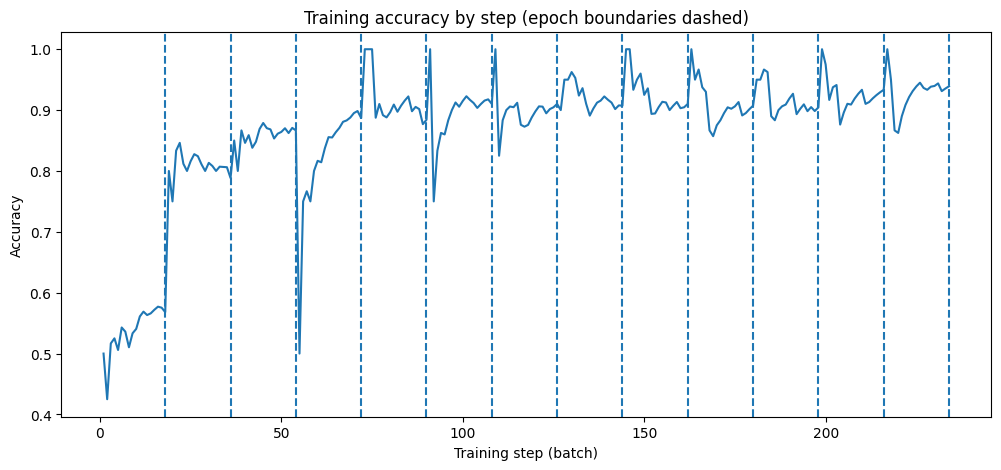

In [10]:
# ---- Plot continuous per-step accuracy with epoch markers ----
steps = np.arange(1, len(batch_hist.batch_acc) + 1)

plt.figure(figsize=(12,5))
plt.plot(steps, batch_hist.batch_acc)
for e_end in batch_hist.epoch_ends:
    plt.axvline(e_end, linestyle="--")  # epoch boundary markers
plt.xlabel("Training step (batch)")
plt.ylabel("Accuracy")
plt.title("Training accuracy by step (epoch boundaries dashed)")
plt.show()

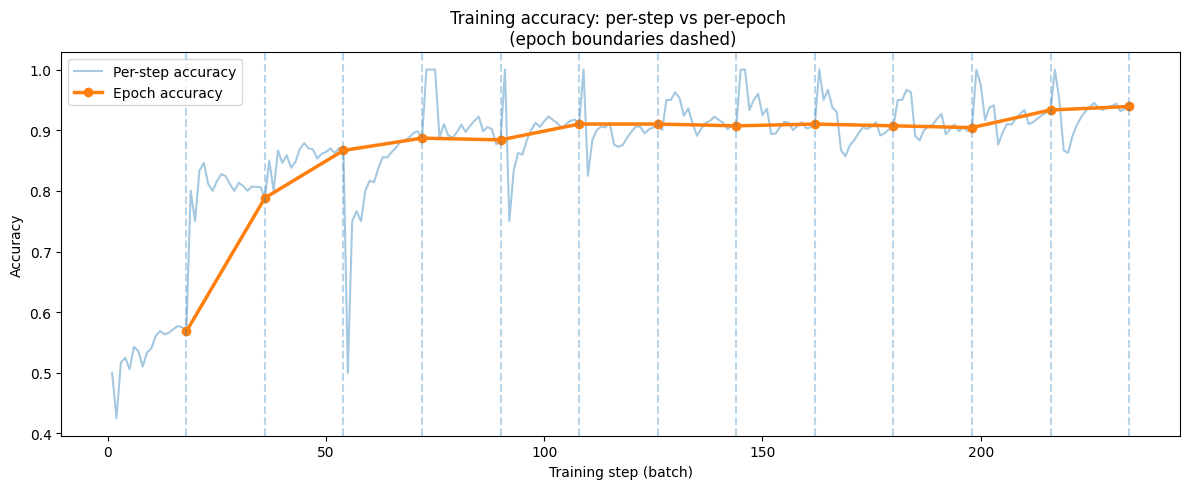

In [16]:
# Continuous steps
steps = np.arange(1, len(batch_hist.batch_acc) + 1)

# Epoch accuracy from Keras history
epoch_acc = history.history["accuracy"]

plt.figure(figsize=(12, 5))

# Per-step accuracy (noisy)
plt.plot(steps, batch_hist.batch_acc, alpha=0.4, label="Per-step accuracy")

# Epoch accuracy projected onto step axis
epoch_step_x = batch_hist.epoch_ends
plt.plot(
    epoch_step_x,
    epoch_acc,
    marker="o",
    linewidth=2.5,
    label="Epoch accuracy"
)

# Epoch boundaries
for e_end in batch_hist.epoch_ends:
    plt.axvline(e_end, linestyle="--", alpha=0.3)

plt.xlabel("Training step (batch)")
plt.ylabel("Accuracy")
plt.title("Training accuracy: per-step vs per-epoch \n (epoch boundaries dashed)")
plt.legend()
plt.tight_layout()
plt.show()


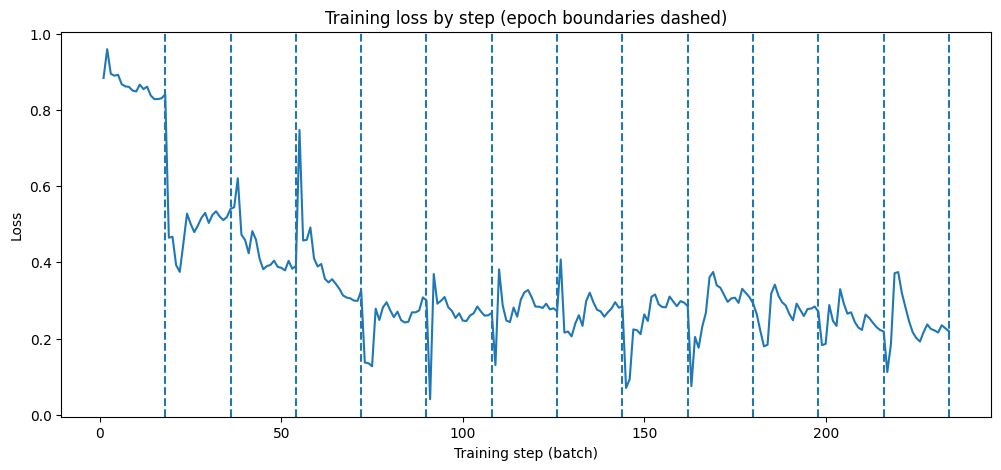

In [11]:
# ---- Optional: loss too ----
plt.figure(figsize=(12,5))
plt.plot(steps, batch_hist.batch_loss)
for e_end in batch_hist.epoch_ends:
    plt.axvline(e_end, linestyle="--")
plt.xlabel("Training step (batch)")
plt.ylabel("Loss")
plt.title("Training loss by step (epoch boundaries dashed)")
plt.show()

# Train Model - old version with less detailed tracking

In [14]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[earlystop, checkpoint],
    verbose=1
)

Epoch 1/30


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5779 - loss: 0.8409
Epoch 1: val_loss improved from inf to 1.71629, saving model to model.celeb_man_female.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5771 - loss: 0.8428 - val_accuracy: 0.5057 - val_loss: 1.7163
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6772 - loss: 0.6429
Epoch 2: val_loss did not improve from 1.71629
18/18 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.6801 - loss: 0.6389 - val_accuracy: 0.4483 - val_loss: 2.7495
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8861 - loss: 0.3584
Epoch 3: val_loss improved from 1.71629 to 1.24683, saving model to model.celeb_man_female.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8832 - loss: 0.3623 - val_accuracy: 0.5402 - val_loss: 1.2468
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8964 - loss: 0.3247
Epoch 4: val_loss did not improve from 1.24683
18/18 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy:

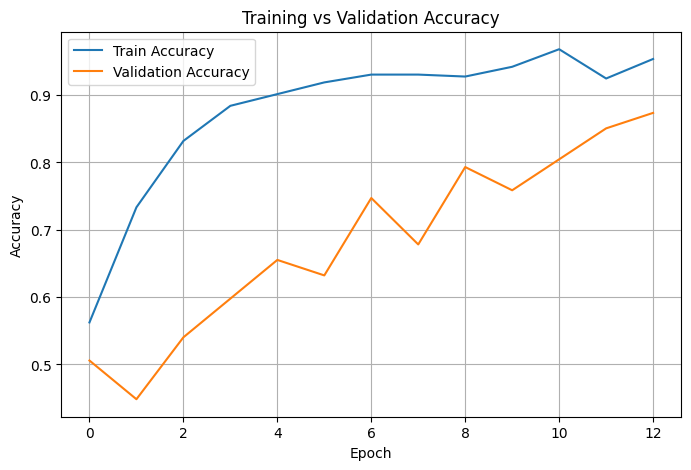

In [16]:
# Plot Accuracy by Epoch
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# What was the most confident incorrect prediction?